## Project 2
Classification
10 points total

Program 1
Generate a dataset:
- 2 dimensions - x1, x2
- 4 classes (arbitrary)
- 50 data points per class, 200 total


The standard deviation, shape, and location of the cluster centers are left to your decision.
Divide the data into a training and testing sets in a 80/20 ratio.


Visualise the dataset.
Write and train three multi-class classifiers:
1. Using a combinations of binary perceptrons, with a
    - One-versus-one strategy, or
    - One-versus-rest strategy
2. Using logistic regression. Use the softmax function.

Visualise the accuracy of each classifier based on the test set.
Write a 1-2 sentence comparison of approaches.




In [2]:
from typing import Literal

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from numpy import ndarray

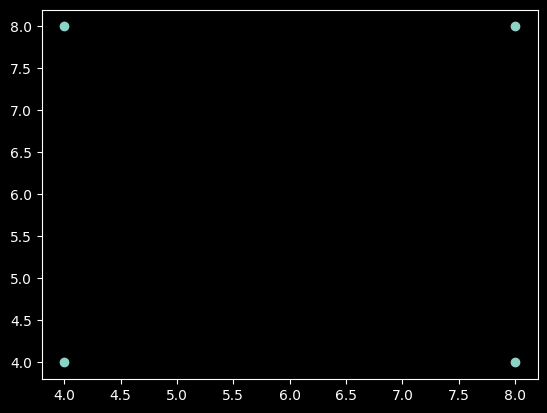

In [12]:
centroids = [(4, 4), (8,4), (4, 8), (8,8)]

standard_deviation = 0.9

x_centroids = [t[0] for t in centroids]
y_centroids = [t[1] for t in centroids]

plt.scatter([t[0] for t in centroids], [t[1] for t in centroids])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


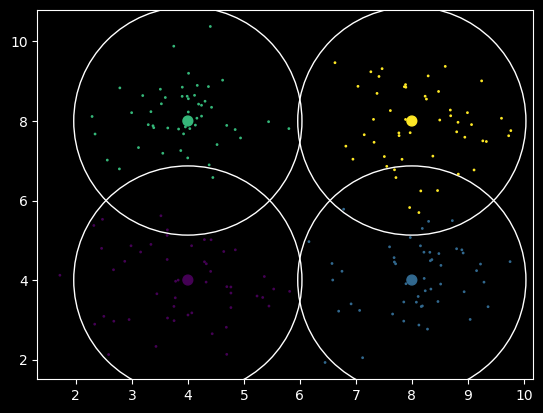

In [13]:
# generate data

# order between X and Y arrays has to be maintained
# X = features
X = []
# y = labels
y = []

samples_per_class = 50
dimensionality_of_features = 2

for i, centroid in enumerate(centroids):
    samples = np.random.randn(samples_per_class, dimensionality_of_features)
    samples = samples * standard_deviation + centroid
    X.append(samples)
    y.append([i] * samples_per_class)

X = np.concatenate(X)
y = np.concatenate(y)

print(type(X))
print(type(y))

a = ndarray

colors_of_centroids = np.unique(y)
colors_of_samples = y
size_of_centroids_range = standard_deviation * 1000 * 30
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], facecolors='none', edgecolors='white', s=size_of_centroids_range)
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], c=colors_of_centroids, s=50)
plt.scatter(X[:,0], X[:,1], c=colors_of_samples, s=1)

In [15]:
class Perceptron:

    def __init__(self, dimensionality):
        # parameters
        self.weights = np.random.rand(dimensionality) * 2 - 1 # weights in range from -1 to 1
        self.bias = np.random.rand()
        self.learning_rate = 0.1
        self.epochs = 10
        self.activation = lambda x: 1 if x > 0 else 0

        # metrics
        self.correct_classifications = 0
        self.all_classifications = 0

    def _forward(self, feature: np.ndarray) -> Literal[0,1]:
        product = np.dot(feature, self.weights)
        product = product + self.bias
        result = self.activation(product)
        assert result in [0,1], "Perceptron should be binary."
        return result

    def _backwards(self, feature: np.ndarray, error: Literal[-1, 0, 1]):

        self.all_classifications += 1
        self.correct_classifications += abs(abs(error) - 1)

        self.bias += error * self.learning_rate
        for dimension in range(len(self.weights)):
            self.weights[dimension] += feature[dimension] * error * self.learning_rate

    def learn(self, features: np.ndarray, labels: np.ndarray):
        for epoch in range(0,self.epochs):
            for feature, label in zip(features,labels):
                # predict
                predicted_label = self._forward(feature)
                # compute error of prediction
                error = label - predicted_label
                # adjust Perceptron according to erro
                self._backwards(feature, error)
            print("epoch: " + str(epoch) + " | accuracy: " +
                  str(self.correct_classifications / self.all_classifications))
            self.all_classifications = 0
            self.correct_classifications = 0


    def predict(self, features: np.ndarray) -> np.ndarray:
        predicted_labels = [self._forward(feature) for feature in features]
        return np.array(predicted_labels)

    def predict(self, feature) -> Literal[0, 1]:
        predicted_label = self._forward(feature)
        return predicted_label

In [24]:
# smoke test
def yield_accuracy_of_predictions(p: Perceptron, features_set, labels_set):
    predictions = p.predict(X)
    correct = 0

    for true_label, prediction in zip(y, predictions):
        if true_label == prediction:
            correct += 1

    return str(correct / len(predictions))

test_perceptron = Perceptron(dimensionality=2)

accuracy = yield_accuracy_of_predictions(p=test_perceptron, features_set=X, labels_set=y)
print("accuracy: " + accuracy)
assert (0.20 < float(accuracy) < 0.30), "A single four-class perceptron without any training should have 25% accuracy."

accuracy: 0.25


### One vs Rest

In [31]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

# Perceptron 0
y_0 = np.array([0 if e == 0 else 1 for e in labels_train_set])
perceptron_0 = Perceptron(dimensionality=2)
perceptron_0.learn(features_train_set,y_0)
# Perceptron 1
y_1 = np.array([0 if e == 1 else 1 for e in labels_train_set])
perceptron_1 = Perceptron(dimensionality=2)
perceptron_1.learn(features_train_set,y_1)
# Perceptron 2
y_2 = np.array([0 if e == 2 else 1 for e in labels_train_set])
perceptron_2 = Perceptron(dimensionality=2)
perceptron_2.learn(features_train_set,y_2)
# Perceptron 3
y_3 = np.array([0 if e == 3 else 1 for e in labels_train_set])
perceptron_3 = Perceptron(dimensionality=2)
perceptron_3.learn(features_train_set,y_3)


def one_vs_rest_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []
    perceptron_label_dict = { perceptron_0: 0, perceptron_1: 1, perceptron_2: 2, perceptron_3: 3}

    for feature in features:
        for perceptron in perceptron_label_dict:
            if perceptron.predict(feature) == 0:
                predicted_labels.append(perceptron_label_dict.get(perceptron))
        # print("Perceptron 0 output:" + str(perceptron_0.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 1 output:" + str(perceptron_1.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 2 output:" + str(perceptron_2.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 3 output:" + str(perceptron_3.predict(np.array([feature]))))
    return predicted_labels_of_one_vs_all

predicted_labels_of_one_vs_all = one_vs_rest_classification(features_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_of_one_vs_all, labels_test_set):
    if predicted_label == true_label:
        correct += 1

print("Accuracy of One vs Rest classification: " + str(correct/len(labels_test_set)))

epoch: 0 | accuracy: 0.675
epoch: 1 | accuracy: 0.73125
epoch: 2 | accuracy: 0.71875
epoch: 3 | accuracy: 0.70625
epoch: 4 | accuracy: 0.7625
epoch: 5 | accuracy: 0.7875
epoch: 6 | accuracy: 0.76875
epoch: 7 | accuracy: 0.83125
epoch: 8 | accuracy: 0.85625
epoch: 9 | accuracy: 0.875
epoch: 0 | accuracy: 0.7625
epoch: 1 | accuracy: 0.8125
epoch: 2 | accuracy: 0.9125
epoch: 3 | accuracy: 0.88125
epoch: 4 | accuracy: 0.86875
epoch: 5 | accuracy: 0.90625
epoch: 6 | accuracy: 0.86875
epoch: 7 | accuracy: 0.89375
epoch: 8 | accuracy: 0.90625
epoch: 9 | accuracy: 0.89375
epoch: 0 | accuracy: 0.825
epoch: 1 | accuracy: 0.88125
epoch: 2 | accuracy: 0.9375
epoch: 3 | accuracy: 0.91875
epoch: 4 | accuracy: 0.9375
epoch: 5 | accuracy: 0.925
epoch: 6 | accuracy: 0.925
epoch: 7 | accuracy: 0.95625
epoch: 8 | accuracy: 0.94375
epoch: 9 | accuracy: 0.94375
epoch: 0 | accuracy: 0.5625
epoch: 1 | accuracy: 0.625
epoch: 2 | accuracy: 0.61875
epoch: 3 | accuracy: 0.6375
epoch: 4 | accuracy: 0.65625
epoch:

Traceback (most recent call last):
  File "/Users/jeremi.lipniacki/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev/_pydevd_bundle/pydevd_comm.py", line 736, in make_thread_stack_str
    append('file="%s" line="%s">' % (make_valid_xml_value(my_file), lineno))
                                     ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "/Users/jeremi.lipniacki/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev/_pydevd_bundle/pydevd_xml.py", line 36, in make_valid_xml_value
    return s.replace("&", "&amp;").replace('<', '&lt;').replace('>', '&gt;').replace('"', '&quot;')
           ^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'replace'


KeyboardInterrupt: 